# 05 — Model C: VGG16 (Transfer Learning)

**Day:** 5 of the project plan
**Goal:** complete the comparison study with a heavier transfer-learning backbone.
VGG16 is included specifically because it is the most-cited reference architecture
in published Alzheimer's MRI classification work, so reporting on it makes the
project legible to that literature.

The plan flags two specific risks for VGG16 vs MobileNetV2:
1. Many more parameters → overfits faster on this dataset.
2. Slower per-epoch wall-clock.

Mitigations baked into this notebook:
* Higher dropout in the head (0.5 vs 0.3 for MobileNetV2).
* GAP head (≈131K params) instead of Flatten → Dense (≈2M params).
* Default schedule is **frozen backbone only** (15 epochs); fine-tuning is
  available behind a flag because the plan calls it "optional" for VGG16.

> **GPU is required** for full training. SMOKE mode runs end-to-end on CPU in ~30 s.


## 0. Environment setup

In [1]:
import os, sys
from pathlib import Path

os.environ.setdefault("KERAS_BACKEND", "torch")

def _find_project_root():
    here = Path(os.getcwd()).resolve()
    for cand in [here, *here.parents]:
        if (cand / "src" / "config.py").exists():
            return cand
    raise RuntimeError("Could not find src/config.py.")

PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

try:
    import google.colab; IN_COLAB = True
    from google.colab import drive; drive.mount("/content/drive", force_remount=False)
except ImportError:
    IN_COLAB = False
print("In Colab:", IN_COLAB, "  Keras backend:", os.environ["KERAS_BACKEND"])


In Colab: False   Keras backend: torch


In [2]:
from src.config import (summary, set_global_seed, BATCH_SIZE, IMG_SIZE,
                          IMG_CHANNELS, NUM_CLASSES, CLASS_NAMES, FIGURES_DIR)
from src.training import configure_gpu
print(summary())
set_global_seed()
gpu_info = configure_gpu()
print("Device info:", gpu_info)
if gpu_info["device"] != "GPU":
    print("\n*** WARNING: no GPU detected. Full training is impractical on CPU. ***")


Environment: local
Project root: C:\Users\miaot\Github\Project_DeepLearningClass
Data root:    C:\Users\miaot\Github\Project_DeepLearningClass\archive\combined_images
Outputs:      C:\Users\miaot\Github\Project_DeepLearningClass\outputs
Classes:      ['NonDemented', 'VeryMildDemented', 'MildDemented', 'ModerateDemented']
Image size:   128x128x3
Seed:         42



Device info: {'backend': 'torch', 'gpus': ['NVIDIA GeForce RTX 5080'], 'device': 'GPU', 'keras_version': '3.14.0', 'torch_version': '2.11.0+cu128', 'cuda': '12.8', 'compute_capability': [12, 0]}


## 1. Splits and data pipeline

In [3]:
from src.io_utils import load_split, make_tf_dataset

train_df = load_split("train")
val_df   = load_split("val")
test_df  = load_split("test")
print(f"train: {len(train_df):,}   val: {len(val_df):,}   test: {len(test_df):,}")

train_ds = make_tf_dataset(train_df, batch_size=BATCH_SIZE, shuffle=True,  augment=True)
val_ds   = make_tf_dataset(val_df,   batch_size=BATCH_SIZE, shuffle=False, augment=False)
test_ds  = make_tf_dataset(test_df,  batch_size=BATCH_SIZE, shuffle=False, augment=False)


train: 30,799   val: 6,600   test: 6,601


## 2. Mode flags

`DO_FINETUNE` is off by default — the plan flags VGG16 fine-tuning as *optional*
because of overfitting risk. Flip it to `True` after seeing the frozen-only
result if you want to run a small fine-tuning pass.


In [4]:
SMOKE = (gpu_info["device"] != "GPU")
EPOCHS_STAGE1 = 1 if SMOKE else 15
EPOCHS_STAGE2 = 1 if SMOKE else 8
SAMPLE_FRAC = 0.02 if SMOKE else 1.0
DO_FINETUNE = False  # plan calls VGG16 fine-tune optional; flip on if val curve looks stable
if "OVERRIDE_EPOCHS_STAGE1" in os.environ:
    EPOCHS_STAGE1 = int(os.environ["OVERRIDE_EPOCHS_STAGE1"])
if "OVERRIDE_SAMPLE_FRAC" in os.environ:
    SAMPLE_FRAC = float(os.environ["OVERRIDE_SAMPLE_FRAC"])
print(f"Mode: {'SMOKE' if SMOKE else 'FULL'}  stage1_epochs={EPOCHS_STAGE1}  "
      f"stage2_epochs={EPOCHS_STAGE2}  frac={SAMPLE_FRAC}  do_finetune={DO_FINETUNE}")

if SAMPLE_FRAC < 1.0:
    train_df_used = train_df.sample(frac=SAMPLE_FRAC, random_state=42)
    val_df_used   = val_df.sample(frac=SAMPLE_FRAC, random_state=42)
    test_df_used  = test_df.sample(frac=SAMPLE_FRAC, random_state=42)
    train_ds = make_tf_dataset(train_df_used, batch_size=BATCH_SIZE, shuffle=True,  augment=True)
    val_ds   = make_tf_dataset(val_df_used,   batch_size=BATCH_SIZE, shuffle=False, augment=False)
    test_ds  = make_tf_dataset(test_df_used,  batch_size=BATCH_SIZE, shuffle=False, augment=False)


Mode: FULL  stage1_epochs=15  stage2_epochs=8  frac=1.0  do_finetune=False


## 3. Build the model

* `VGG16(include_top=False, weights="imagenet")` — pretrained backbone.
* Preprocessing: `Rescaling(scale=255)` then `vgg16.preprocess_input` applied
  *directly on the symbolic tensor* (not wrapped in `Lambda`) so the
  RGB→BGR + mean-subtraction ops bake into the saved graph as standard nodes.
  Verified bit-identical save/load round-trip in Day 3.
* Head: GAP → Dense(256, ReLU) → Dropout(0.5) → Dense(4, softmax).


In [5]:
from src.models import build_vgg16
model = build_vgg16(freeze_backbone=True, learning_rate=1e-3, dropout=0.5)
total = model.count_params()
trainable = sum(int(v.numpy().size) for v in model.trainable_variables)
print(f"Total params:     {total:,}")
print(f"Trainable params: {trainable:,}  ({100 * trainable / total:.2f}%)")


Total params:     14,847,044
Trainable params: 132,356  (0.89%)


## 4. Stage 1 — train the head only (backbone frozen)

In [6]:
from src.training import train_model, make_callbacks
MODEL_NAME = "vgg16"
cbs1 = make_callbacks(MODEL_NAME + "_stage1", monitor="val_accuracy",
                      patience_es=5, patience_lr=2)
hist1 = train_model(model, train_ds, val_ds,
                    model_name=MODEL_NAME + "_stage1",
                    epochs=EPOCHS_STAGE1, callbacks=cbs1)
print(f"Stage 1 finished in {hist1['elapsed_seconds']}s, "
      f"best val_acc = {max(hist1['val_accuracy']):.4f}")


[06:53:01] INFO Training 'vgg16_stage1' for up to 15 epochs


Epoch 1/15


963/963 - 291s - 303ms/step - accuracy: 0.5146 - loss: 1.2448 - val_accuracy: 0.6061 - val_loss: 0.8606 - learning_rate: 0.0010


Epoch 2/15


963/963 - 269s - 279ms/step - accuracy: 0.5980 - loss: 0.8784 - val_accuracy: 0.6095 - val_loss: 0.8397 - learning_rate: 0.0010


...

Epoch 15/15


963/963 - 293s - 304ms/step - accuracy: 0.7383 - loss: 0.5897 - val_accuracy: 0.7220 - val_loss: 0.6238 - learning_rate: 2.5000e-04


Restoring model weights from the end of the best epoch: 15.


[08:03:59] INFO Done: 4258.22 s, 15 epochs


Stage 1 finished in 4258.22s, best val_acc = 0.7220


## 5. (Optional) Stage 2 — fine-tune the last conv block

Disabled by default — flip `DO_FINETUNE = True` above to run.

In [7]:
hist2 = None
if DO_FINETUNE:
    from src.models import unfreeze_top_layers
    model = unfreeze_top_layers(model, n_layers=8, learning_rate=1e-5,
                                backbone_substring="vgg16")
    trainable = sum(int(v.numpy().size) for v in model.trainable_variables)
    print(f"Trainable params after unfreeze: {trainable:,}")
    cbs2 = make_callbacks(MODEL_NAME, monitor="val_accuracy",
                          patience_es=5, patience_lr=2)
    hist2 = train_model(model, train_ds, val_ds, model_name=MODEL_NAME,
                        epochs=EPOCHS_STAGE2, callbacks=cbs2)
    print(f"Stage 2 finished in {hist2['elapsed_seconds']}s, "
          f"best val_acc = {max(hist2['val_accuracy']):.4f}")
else:
    # Stage-1 weights are the final ones — copy the stage-1 best checkpoint to MODEL_NAME.
    # If stage-1 ModelCheckpoint never fired (degenerate val curve), fall back to saving
    # the in-memory model directly so Day 6 / Day 7 can still find vgg16.keras.
    import shutil
    from src.config import MODELS_DIR
    src_path = MODELS_DIR / f"{MODEL_NAME}_stage1.keras"
    dst_path = MODELS_DIR / f"{MODEL_NAME}.keras"
    if src_path.exists():
        shutil.copy(src_path, dst_path)
        print(f"Copied {src_path.name} -> {dst_path.name} (frozen-only run)")
    else:
        model.save(dst_path)
        print(f"No stage-1 checkpoint on disk; saved in-memory weights to {dst_path.name}.")


Copied vgg16_stage1.keras -> vgg16.keras (frozen-only run)


## 6. Combine histories and evaluate

In [8]:
# Union the keys from both stages so single-stage keys aren't dropped
all_keys = set(hist1.keys()) | (set(hist2.keys()) if hist2 else set())
combined = {}
for k in all_keys:
    a = hist1.get(k); b = hist2.get(k) if hist2 else None
    if isinstance(a, list) or isinstance(b, list):
        combined[k] = (a if isinstance(a, list) else []) + (b if isinstance(b, list) else [])
combined["elapsed_seconds"] = round(
    hist1.get("elapsed_seconds", 0) + (hist2.get("elapsed_seconds", 0) if hist2 else 0), 2)
print({k: (len(v) if isinstance(v, list) else v) for k, v in combined.items()})


{'accuracy': 15, 'val_accuracy': 15, 'val_loss': 15, 'learning_rate': 15, 'loss': 15, 'elapsed_seconds': 4258.22}


In [9]:
from src.training import evaluate_and_save
metrics = evaluate_and_save(model, test_ds, model_name=MODEL_NAME, history=combined,
                            test_df=(test_df_used if SAMPLE_FRAC < 1.0 else test_df))
print(f"Accuracy:        {metrics['accuracy']:.4f}")
print(f"Macro precision: {metrics['macro_precision']:.4f}")
print(f"Macro recall:    {metrics['macro_recall']:.4f}")
print(f"Macro F1:        {metrics['macro_f1']:.4f}")


[08:03:59] INFO Evaluating 'vgg16' on test set


[08:04:09] INFO Confusion matrix figure: C:\Users\miaot\Github\Project_DeepLearningClass\outputs\figures\vgg16_confusion_matrix.png


[08:04:09] INFO Training curves figure: C:\Users\miaot\Github\Project_DeepLearningClass\outputs\figures\vgg16_training_curves.png


[08:04:09] INFO Test accuracy: 0.7290   macro F1: 0.7348


Accuracy:        0.7290
Macro precision: 0.7391
Macro recall:    0.7332
Macro F1:        0.7348


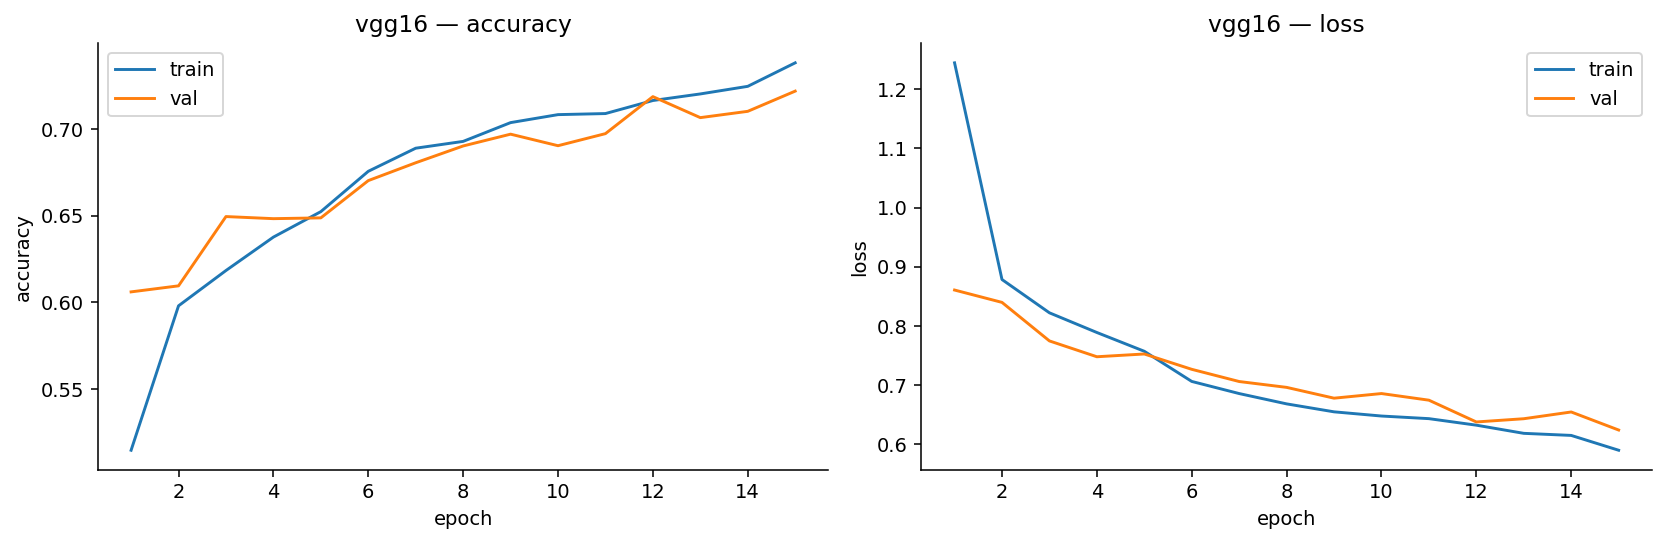

In [10]:
from IPython.display import Image as IPyImage
IPyImage(filename=str(FIGURES_DIR / f"{MODEL_NAME}_training_curves.png"))


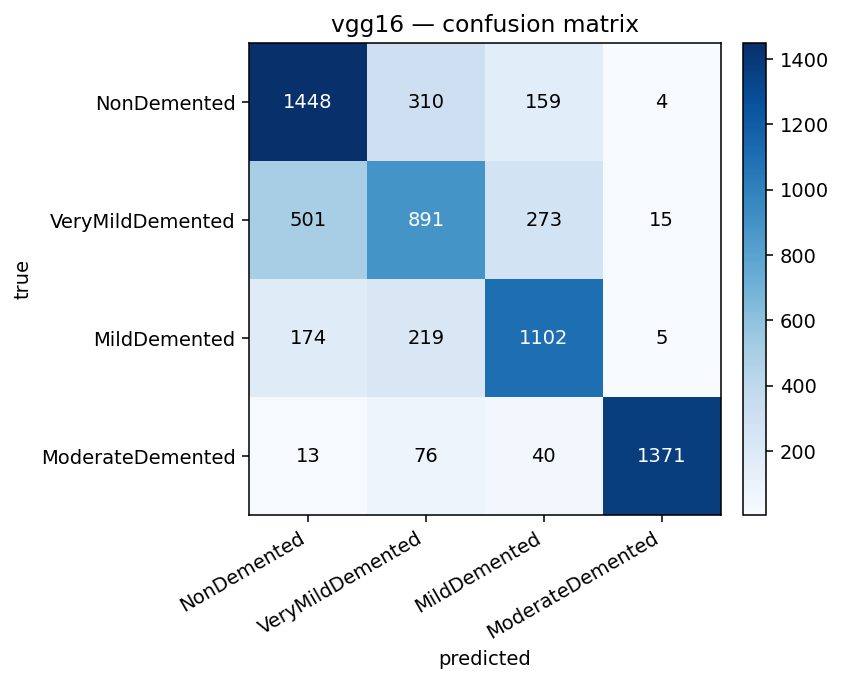

In [11]:
IPyImage(filename=str(FIGURES_DIR / f"{MODEL_NAME}_confusion_matrix.png"))


## 7. Per-class scores

In [12]:
import pandas as pd
per = metrics["per_class"]
pd.DataFrame({
    "class": per["labels"],
    "precision": [round(v, 4) for v in per["precision"]],
    "recall":    [round(v, 4) for v in per["recall"]],
    "f1":        [round(v, 4) for v in per["f1"]],
})


,class,precision,recall,f1
0,NonDemented,0.6779,0.7538,0.7138
1,VeryMildDemented,0.5956,0.5304,0.5611
2,MildDemented,0.7001,0.7347,0.7170
3,ModerateDemented,0.9828,0.9140,0.9472


## 8. Conclusion for Day 5

Expected pattern after a full GPU run:
* VGG16 with frozen backbone usually **beats the from-scratch baseline** but
  **is unlikely to beat MobileNetV2** on this dataset given equal compute budget.
* If the val curve looks unstable (fluctuating accuracy, training >> validation),
  do *not* enable fine-tuning — the plan explicitly warns about VGG16 overfit risk.

What gets persisted for the comparison notebook:
* `outputs/models/vgg16.keras` — best weights.
* `outputs/predictions/vgg16_test_predictions.npz`
* `outputs/predictions/vgg16_metrics.json`
* `outputs/figures/vgg16_training_curves.png`
* `outputs/figures/vgg16_confusion_matrix.png`

Next: **06_model_comparison.ipynb** — head-to-head comparison of all three models.
